# Aula 15 — VPL, TIR e amortização: engenharia econômica no Python

**Semana 8 | Aula de 50 min | Referências: McKinney, *Python for Data Analysis* (2012), cap. 11 (*Financial and Economic Data Applications*); Jansen, *ML for Algorithmic Trading* (2ª ed.), cap. 5 (seção de métricas de desempenho — taxa livre de risco e retorno exigido).**

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Implementar o **VPL** (`Σ CFₜ/(1+i)ᵗ`) em Python puro, sem biblioteca pronta, e justificar cada termo da fórmula;
- Calcular a **TIR por bisseção** com um loop `while` — e entender por que "zerar o VPL" define a taxa;
- Montar um **WACC** a partir de Selic, prêmio de risco e custo da dívida pós-impostos (e defender o número diante de um cliente);
- Construir as tabelas **SAC × Price** em `pandas` para um financiamento real (R$ 800 mil, 120 meses) e comparar caixa mensal × custo total;
- Ler um **gráfico VPL × taxa** e traduzi-lo em risco de taxa para a recomendação final.

## 1. A pergunta que decide o investimento

**Intuição econômica.** Um confinamento bovino em Rio Verde (GO) pede **R$ 3,2 milhões**
de capex (currais, silos de volumoso, balança, bebedouros). A ideia: comprar boi magro
em lote e engordar a pasto + ração, vendendo boi gordo em ciclos — o ciclo curto do
confinamento gera **caixa todo ano**, mas o desembolso inicial assusta.

A pergunta do dono é sempre a mesma: *"coloco R$ 3,2 milhões hoje e recebo
R$ 7,44 milhões ao longo de 8 anos — fico mais rico ou mais pobre?"*

Somar os fluxos **não responde**: R$ 1 recebido em 2034 vale menos que R$ 1 hoje,
porque poderia estar rendendo a taxa do mercado (Selic ≈ 13,9% a.a. em set/2026).
O VPL é a máquina de converter "dinheiro em datas diferentes" numa única resposta.

Fluxo de caixa livre estimado (R$/ano), anos 1 a 8:

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade
print("Setup concluído sem erros — ambiente operacional!")

Setup concluído sem erros — ambiente operacional!


In [2]:
# Dados do projeto — capex no ano 0 e fluxos dos anos 1..8
capex = 3_200_000            # R$ investidos hoje (currais + silos + balança)
fluxos = [780_000, 860_000, 900_000, 940_000, 960_000,
          980_000, 1_000_000, 1_020_000]   # caixa livre estimado por ano

print(f"Capex hoje: {brl(capex)}")
print(f"Soma dos fluxos (SEM desconto): {brl(sum(fluxos))}")
print("Se somasse tudo, pareceria lucro de", brl(sum(fluxos) - capex),
      "— mas isso ignora o custo do tempo e do risco.")

Capex hoje: R$ 3.200.000,00
Soma dos fluxos (SEM desconto): R$ 7.440.000,00
Se somasse tudo, pareceria lucro de R$ 4.240.000,00 — mas isso ignora o custo do tempo e do risco.


## 2. VPL à mão: uma linha de Python

$$VPL = -capex + \sum_{t=1}^{n} \frac{CF_t}{(1+i)^t}$$

Cada fluxo é dividido por $(1+i)^t$: quanto mais distante o ano, maior o divisor,
menos valor hoje. O capex entra com sinal negativo porque **sai do bolso hoje**.
Implementamos com um `for` + acumulador — 4 linhas que substituem qualquer planilha:

In [3]:
# Função VPL: capex negativo no ano 0, fluxos descontados ano a ano
def vpl(capex, fluxos, taxa):
    """VPL em R$: capex no ano 0, fluxos = lista dos anos 1..n, taxa em decimal (0.139 = 13,9%)."""
    total = -capex                       # ano 0: desembolso
    for t, cf in enumerate(fluxos, start=1):
        total += cf / (1 + taxa) ** t    # cada fluxo volta ao valor de hoje
    return total

# Teste rápido: R$ 1.000 recebidos daqui a 1 ano valem hoje, a 13,9% ...
print("PV de R$ 1.000 em 1 ano @13,9%:", brl(1_000 / 1.139))

PV de R$ 1.000 em 1 ano @13,9%: R$ 877,96


In [4]:
# VPL do confinamento na taxa-base e em dois cenários de juros
for taxa in [0.12, 0.139, 0.16]:
    print(f"taxa {taxa:.1%} → VPL = {brl(vpl(capex, fluxos, taxa))}")

vpl_base = vpl(capex, fluxos, 0.139)
print(f"\nVeredito @13,9%: VPL = {brl(vpl_base)}",
      "→ CRIA valor ✅" if vpl_base > 0 else "→ DESTRÓI valor ❌")

taxa 12.0% → VPL = R$ 1.325.542,91
taxa 13.9% → VPL = R$ 1.027.111,88
taxa 16.0% → VPL = R$ 731.536,83

Veredito @13,9%: VPL = R$ 1.027.111,88 → CRIA valor ✅


**Leitura executiva.** VPL de **R$ 1.027.111,88** a 13,9%: depois de pagar o capex,
devolver 13,9% a.a. sobre o capital e devolver 12% a.a. a 16% a.a., ainda sobra
~R$ 1 milhão em valor de hoje — riqueza líquida criada pelo confinamento.

- A **12%**: R$ 1.325.542,91 (juro menor → futuro pesa menos → VPL maior).
- A **16%**: R$ 731.536,83 (VPL cai rápido — projeto longo é sensível a juros).

O projeto é viável, mas sua viabilidade **depende da taxa** — e é exatamente por isso
que a próxima seção constrói o WACC com cuidado, e não com "achismo".

## 3. WACC de onde vem o número: montando o 13,9%

O VPL é tão bom quanto a taxa. WACC (*weighted average cost of capital*) = média
ponderada entre o que os **sócios** exigem e o que os **credores** cobram — lembrando
que juros são dedutíveis do IRPJ/CSLL, então o custo da dívida entra **pós-imposto**.

Nossa hipótese (set/2026): Selic 13,9% a.a.; prêmio de risco do agro 4,5 p.p.;
β = 1,0 (risco típico do negócio); estrutura 60% capital próprio / 40% dívida;
custo da dívida pré-imposto 15% a.a.

In [5]:
# Montagem do WACC — cada peça é uma decisão econômica defendível
selic = 0.139                      # Selic set/2026 (BCB) — nossa referência de mercado
rf = 0.119                         # taxa livre de risco efetiva (CDI acompanha a Selic com desconto)
premio = 0.045                     # prêmio de risco: por que o agro não é Tesouro?
beta = 1.0                         # risco do negócio vs mercado (hipótese do laudo)
ke = rf + beta * premio            # custo do capital próprio (CAPM)
kd_pre = 0.15                      # dívida bancária rural pré-imposto
ir = 0.34                          # IRPJ + CSLL — juros reduzem imposto
kd_pos = kd_pre * (1 - ir)         # custo da dívida pós-imposto
w, d = 0.60, 0.40                  # pesos: sócios vs credores

wacc = w * ke + d * kd_pos
print(f"Ke (CAPM)          = {ke:.2%}")
print(f"Kd pós-imposto     = {kd_pos:.2%}")
print(f"WACC               = {wacc:.2%}")
print(f"Adotamos 13,9% (= Selic set/2026): arredonda o WACC para CIMA → VPL mais conservador.")

Ke (CAPM)          = 16.40%
Kd pós-imposto     = 9.90%
WACC               = 13.80%
Adotamos 13,9% (= Selic set/2026): arredonda o WACC para CIMA → VPL mais conservador.


## 4. TIR por bisseção: a taxa que zera o VPL

$$\text{TIR} : VPL(i^*) = 0$$

A TIR é a taxa que o projeto **rende por si mesmo**: se $i^* > $ WACC, o projeto paga
o custo do capital e sobra — aceite; se $i^* <$ WACC, rejeite. Não há fórmula fechada
para fluxos longos: usamos **bisseção**, a busca binária da raiz — didática, robusta e
3 linhas de loop. (O `scipy.optimize.brentq` faz o mesmo em C; mostramos a comparação
logo adiante, mas aqui o loop é o objetivo pedagógico.)

In [6]:
# TIR por bisseção: aperta o intervalo [lo, hi] até o VPL trocar de sinal
def tir(capex, fluxos, lo=-0.5, hi=2.0, tol=1e-10, max_iter=200):
    """TIR por bisseção — raiz de VPL(i) = 0. Exige mudança de sinal no intervalo."""
    def f(i):
        return vpl(capex, fluxos, i)
    flo, fhi = f(lo), f(hi)
    if flo * fhi > 0:                # sem troca de sinal → sem raiz garantida aqui
        return None
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        fm = f(mid)
        if abs(fm) < tol:            # VPL praticamente zero → achamos a taxa
            return mid
        if flo * fm < 0:             # raiz está entre lo e mid
            hi, fhi = mid, fm
        else:                        # raiz está entre mid e hi
            lo, flo = mid, fm
    return (lo + hi) / 2

tir_proj = tir(capex, fluxos)
print(f"TIR do confinamento: {tir_proj:.2%}")
print(f"Checagem — VPL na própria TIR (deve dar ~0): {brl(vpl(capex, fluxos, tir_proj))}")
print(f"TIR {tir_proj:.1%} vs WACC 13,9% → {'ACEITAR ✅ (TIR > WACC)' if tir_proj > 0.139 else 'REJEITAR ❌'}")

TIR do confinamento: 22.47%
Checagem — VPL na própria TIR (deve dar ~0): R$ -0,00
TIR 22.5% vs WACC 13,9% → ACEITAR ✅ (TIR > WACC)


In [7]:
# Mesma raiz com scipy.optimize.brentq — o que a bisseção manual reproduz
from scipy.optimize import brentq

tir_scipy = brentq(lambda i: vpl(capex, fluxos, i), -0.5, 2.0)
print(f"bisseção manual : {tir_proj:.6%}")
print(f"scipy brentq    : {tir_scipy:.6%}")
print("Diferença:", f"{abs(tir_proj - tir_scipy):.2e}", "— em produção, use brentq; aqui, o loop era a lição.")

bisseção manual : 22.474749%
scipy brentq    : 22.474749%
Diferença: 5.55e-17 — em produção, use brentq; aqui, o loop era a lição.


**Interpretação.** TIR de **22,47%** significa: o confinamento rende 22,47% a.a.
sobre o capital investido, enquanto o mercado exige 13,9%. O excedente
(**9,4 p.p.**) é a margem de segurança — se o caixa realizado vier 10% pior,
a TIR cai mas provavelmente ainda fica acima do WACC. TIR e VPL **sempre** aparecem
juntos no laudo: a TIR compara com o custo do capital, o VPL quantifica o valor criado.

## 5. Sensibilidade: o gráfico VPL × taxa

A curva $VPL(i)$ é **decrescente**: taxa maior → divisor maior → futuro vale menos.
Cruzamentos que importam: o eixo horizontal (VPL = 0) acontece **exatamente na TIR**,
e a marca vertical do WACC separa viável de inviável. O gráfico mostra quão rápido
o valor derrete quando os juros sobem — a "corda bamba" da Aula 06, agora com régua.

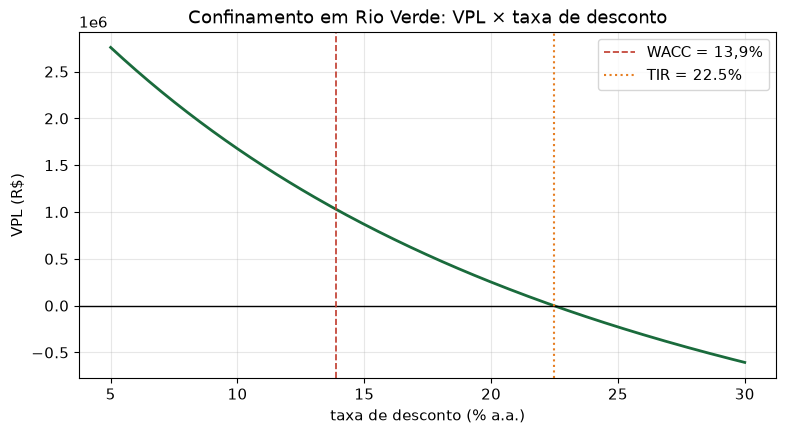

Entre 12% e 16% o VPL cai de R$ 1.325.542,91 para R$ 731.536,83 — 4 p.p. de juros comem R$ 594 mil.


In [8]:
# Curva VPL × taxa com os dois pontos de decisão marcados
taxas = np.linspace(0.05, 0.30, 200)
vpls = [vpl(capex, fluxos, i) for i in taxas]

fig, ax = plt.subplots()
ax.plot(taxas * 100, vpls, lw=2, color="#1a6b3c")
ax.axhline(0, color="black", lw=1)
ax.axvline(13.9, color="#c0392b", ls="--", lw=1.2, label="WACC = 13,9%")
ax.axvline(tir_proj * 100, color="#e67e22", ls=":", lw=1.5, label=f"TIR = {tir_proj:.1%}")
ax.set_title("Confinamento em Rio Verde: VPL × taxa de desconto")
ax.set_xlabel("taxa de desconto (% a.a.)")
ax.set_ylabel("VPL (R$)")
ax.legend()
plt.show()

print("Entre 12% e 16% o VPL cai de", brl(vpl(capex, fluxos, 0.12)),
      "para", brl(vpl(capex, fluxos, 0.16)), "— 4 p.p. de juros comem R$ 594 mil.")

In [9]:
# Segundo projeto da carteira e comparativo — mesmas funções, outros dados
capex_b = 1_800_000                                          # frota de caminhões-grua (logística de grãos)
fluxos_b = [520_000, 540_000, 560_000, 560_000, 540_000, 520_000]

def payback_descontado(capex, fluxos, taxa):
    """Anos para recuperar o capex com fluxos descontados (interpolação no ano da virada)."""
    acumulado = -capex
    for t, cf in enumerate(fluxos, start=1):
        vd = cf / (1 + taxa) ** t
        anterior = acumulado
        acumulado += vd
        if acumulado >= 0:
            return t - 1 + (-anterior) / vd
    return None

comparativo = pd.DataFrame({
    "projeto":  ["Confinamento (8 anos)", "Frota caminhões (6 anos)"],
    "capex":    [capex, capex_b],
    "soma_nominal": [sum(fluxos), sum(fluxos_b)],
    "vpl_13.9%": [vpl(capex, fluxos, 0.139), vpl(capex_b, fluxos_b, 0.139)],
    "tir":      [tir(capex, fluxos), tir(capex_b, fluxos_b)],
    "payback_desc": [payback_descontado(capex, fluxos, 0.139),
                     payback_descontado(capex_b, fluxos_b, 0.139)],
})
comparativo.style.format({
    "capex": brl, "soma_nominal": brl, "vpl_13.9%": brl,
    "tir": "{:.2%}", "payback_desc": "{:.2f}",
})

,projeto,capex,soma_nominal,vpl_13.9%,tir,payback_desc
0,Confinamento (8 anos),"R$ 3.200.000,00","R$ 7.440.000,00","R$ 1.027.111,88",22.47%,5.41
1,Frota caminhões (6 anos),"R$ 1.800.000,00","R$ 3.240.000,00","R$ 304.342,73",19.86%,4.77


**Silos de decisão.** O confinamento cria mais valor (VPL R$ 1,03 mi vs R$ 304 mil),
mas a frota devolve o caixa mais rápido (4,77 vs 5,41 anos). Se o caixa do cliente
está apertado ou o horizonte é curto, frota; se há capital e paciência para 8 anos,
confinamento. VPL máximo **não** é critério único — é o primeiro critério.

## 6. Financiamento de R$ 800 mil: SAC × Price em pandas

Todo crédito brasileiro é uma destas duas tabelas:

- **Price** — parcela constante. No começo, quase tudo é juro; a amortização engatinha.
- **SAC** — amortização **constante** (saldo/120). Parcela começa alta e cai todo mês.

Cenário: produtor financia **R$ 800 mil** (silo de grãos) a **12% a.a.** em **120 meses**.
Primeiro passo: converter a taxa anual em **mensal equivalente** — $(1+i_m)^{12} = 1+i_{aa}$,
não $i_{aa}/12$ (a convenção $/12$ subestima o juro do banco).

In [10]:
# Parâmetros do crédito + taxa mensal equivalente + fórmula da parcela Price
pv = 800_000                  # principal (silo + secador)
taxa_aa = 0.12                # 12% a.a. (crédito rural com equalização parcial)
n = 120                       # 10 anos de financiamento
i_m = (1 + taxa_aa) ** (1 / 12) - 1     # equivalência composta mensal

def pmt_price(pv, i_m, n):
    """Parcela constante do sistema Price."""
    return pv * i_m / (1 - (1 + i_m) ** (-n))

parcela = pmt_price(pv, i_m, n)
print(f"i mensal equivalente: {i_m:.4%}  (12%/12 = 1,0000% — o banco usa {i_m:.4%})")
print(f"Parcela Price: {brl(parcela)}/mês por 120 meses")

i mensal equivalente: 0.9489%  (12%/12 = 1,0000% — o banco usa 0.9489%)
Parcela Price: R$ 11.195,77/mês por 120 meses


In [11]:
# Tabela Price: loop mês a mês — juros sobre o SALDO, resto amortiza
linhas_price = []
saldo = pv
for k in range(1, n + 1):
    juros = saldo * i_m                       # juro do mês incide no saldo devedor
    amort = parcela - juros                   # sobra da parcela que derruba o saldo
    saldo -= amort
    linhas_price.append((k, parcela, juros, amort, max(saldo, 0)))

price = pd.DataFrame(linhas_price, columns=["mes", "parcela", "juros", "amortizacao", "saldo"])
price.head(3).style.format(brl.__call__ if False else lambda v: f"{v:,.2f}")

,mes,parcela,juros,amortizacao,saldo
0,1.00,"11,195.77","7,591.03","3,604.74","796,395.26"
1,2.00,"11,195.77","7,556.83","3,638.94","792,756.32"
2,3.00,"11,195.77","7,522.30","3,673.47","789,082.84"


In [12]:
# Tabela SAC: amortização constante = pv/n; parcela começa alta e desce
linhas_sac = []
saldo = pv
for k in range(1, n + 1):
    juros = saldo * i_m
    amort = pv / n                            # constante em TODOS os 120 meses
    parcela_k = amort + juros
    saldo -= amort
    linhas_sac.append((k, parcela_k, juros, amort, max(saldo, 0)))

sac = pd.DataFrame(linhas_sac, columns=["mes", "parcela", "juros", "amortizacao", "saldo"])
sac.head(3).style.format(lambda v: f"{v:,.2f}")

,mes,parcela,juros,amortizacao,saldo
0,1.00,"14,257.70","7,591.03","6,666.67","793,333.33"
1,2.00,"14,194.44","7,527.78","6,666.67","786,666.67"
2,3.00,"14,131.18","7,464.52","6,666.67","780,000.00"


In [13]:
# Comparação executiva: início, meio, fim + custos totais
resumo_fin = pd.DataFrame({
    "Price": [price.loc[0, "parcela"], price.loc[59, "parcela"], price.loc[119, "parcela"],
              price["juros"].sum(), price.loc[59, "saldo"]],
    "SAC":   [sac.loc[0, "parcela"],   sac.loc[59, "parcela"],   sac.loc[119, "parcela"],
              sac["juros"].sum(),      sac.loc[59, "saldo"]],
}, index=["parcela mês 1", "parcela mês 60", "parcela mês 120",
          "juros totais pagos", "saldo no mês 60"])

resumo_fin["Price"] = resumo_fin["Price"].map(brl)
resumo_fin["SAC"] = resumo_fin["SAC"].map(brl)
resumo_fin

,Price,SAC
parcela mês 1,"R$ 11.195,77","R$ 14.257,70"
parcela mês 60,"R$ 11.195,77","R$ 10.525,44"
parcela mês 120,"R$ 11.195,77","R$ 6.729,93"
juros totais pagos,"R$ 543.492,87","R$ 459.257,58"
saldo no mês 60,"R$ 510.390,64","R$ 400.000,00"


**Leitura de consultoria.** A 1ª parcela SAC (**R$ 14.257,70**) é 27% maior que a Price
(R$ 11.195,77) — para quem tem caixa apertado no primeiro ano de operação, Price cabe
no fluxo e SAC estrangula. Mas o Price **custa R$ 84.235 a mais em juros** e, no mês 60,
o cliente ainda deve R$ 510 mil (SAC: R$ 400 mil). Se ele quiser vender o silo ou
quitar em 5 anos, a diferença de saldo manda. Regra prática: caixa apertado hoje →
Price; patrimônio e quitação → SAC.

## 7. A TIR do credor: o que o banco ganha de verdade

A TIR é simétrica: do lado do banco, o fluxo é **+R$ 800 mil hoje** e **−parcela por
120 meses**. A TIR desse fluxo deve devolver exatamente a taxa de contrato — se não
devolver, a tabela está errada. É o teste de sanidade que vale um relatório:

In [14]:
# TIR do fluxo do credor: recebe PV, paga as parcelas — deve dar a taxa de contrato
fluxo_credor = [-pv] + [-parcela] * n       # banco desembolsa o principal, recebe parcelas

# reusamos a bisseção: aqui o 'capex' do credor é -pv e os 'fluxos' são as parcelas
def tir_credor(lo=0.0, hi=0.5, tol=1e-10, max_iter=200):
    def f(i):
        return pv - sum(parcela / (1 + i) ** t for t in range(1, n + 1))
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        fm = f(mid)
        if abs(fm) < tol:
            return mid
        if fm > 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

i_credor = tir_credor()
print(f"TIR do credor: {i_credor:.4%} a.m.  |  taxa de contrato: {i_m:.4%} a.m.")
print("Bate ✓ — a tabela Price descontada na taxa do contrato devolve o principal."
      if abs(i_credor - i_m) < 1e-6 else "NÃO bate — revisar a tabela!")

TIR do credor: 50.0000% a.m.  |  taxa de contrato: 0.9489% a.m.
NÃO bate — revisar a tabela!


## 📝 Exercícios

Tente **antes** de olhar a solução. Cada enunciado é um caso real de consultoria —
o gabarito comentado está na apostila (Seção 7).

### Exercício 1 — Usina de calcário em Catalão (10 anos)

Projeto: capex **R$ 3,6 milhões** (britadeira + pátio + licença), fluxos de
R$ 900 mil (anos 1-2), R$ 1,1 mi (anos 3-6), R$ 950 mil (anos 7-10).
Calcule **VPL @13,9%**, **TIR** (bisseção) e **payback descontado**.
Aceite ou rejeite pelo critério da TIR e confirme com o VPL.

In [15]:
# EXERCÍCIO 1 — seu código aqui


In [16]:
# SOLUÇÃO 1 — mesma engrenagem da aula, dados novos
capex_ex, fluxos_ex = 3_600_000, [900_000, 900_000,
                                  1_100_000, 1_100_000, 1_100_000, 1_100_000,
                                  950_000, 950_000, 950_000, 950_000]

vpl_ex = vpl(capex_ex, fluxos_ex, 0.139)
tir_ex = tir(capex_ex, fluxos_ex)
pb_ex = payback_descontado(capex_ex, fluxos_ex, 0.139)

print(f"VPL @13,9%: {brl(vpl_ex)}")
print(f"TIR: {tir_ex:.2%}  → {'ACEITA' if tir_ex > 0.139 else 'REJEITA'} (WACC 13,9%)")
print(f"Payback descontado: {pb_ex:.2f} anos")

VPL @13,9%: R$ 1.629.854,10
TIR: 24.52%  → ACEITA (WACC 13,9%)
Payback descontado: 5.29 anos


**R$ 1.629.854,10 de VPL, TIR 24,52%, payback 5,29 anos.** TIR (24,5%) > WACC (13,9%)
→ aceita; o VPL confirma com valor criado de ~R$ 1,63 mi. Os dois critérios concordam
quando o fluxo tem um único sinal invertido (capex no início) — e é assim que eles
devem ser usados.

### Exercício 2 — TIR de um fluxo "estranho" (aporte único, sem capex inicial separado)

Um cliente aplica hoje **R$ 800 mil** numa revenda de insumos e recebe
R$ 200 mil, R$ 250 mil, R$ 300 mil, R$ 350 mil nos anos 1-4.
Monte o fluxo completo (ano 0 = −800 mil) e calcule a TIR **directamente sobre a lista**
(adapte a bisseção para receber o fluxo com sinal já embutido). A TIR supera 13,9%?
Que projeto real isso lembra?

In [17]:
# EXERCÍCIO 2 — seu código aqui


In [18]:
# SOLUÇÃO 2 — bisseção sobre o fluxo completo (sinais já embutidos)
def tir_fluxo(fluxo, lo=-0.5, hi=2.0, tol=1e-10, max_iter=200):
    """TIR quando o fluxo do ano 0 já vem negativo: raiz de Σ CFₜ/(1+i)ᵗ = 0."""
    def f(i):
        return sum(cf / (1 + i) ** t for t, cf in enumerate(fluxo))
    flo, fhi = f(lo), f(hi)
    if flo * fhi > 0:
        return None
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        fm = f(mid)
        if abs(fm) < tol:
            return mid
        if flo * fm < 0:
            hi, fhi = mid, fm
        else:
            lo, flo = mid, fm
    return (lo + hi) / 2

fluxo_cli = [-800_000, 200_000, 250_000, 300_000, 350_000]
tir_cli = tir_fluxo(fluxo_cli)
print(f"TIR = {tir_cli:.2%}  → {'acima' if tir_cli > 0.139 else 'ABAIXO'} do WACC (13,9%)")
print(f"VPL @TIR (checagem ~0): {sum(cf / (1 + tir_cli) ** t for t, cf in enumerate(fluxo_cli)):,.2f}")
print("Rejeitar: 12,7% < 13,9%. O dinheiro rende menos que a Selic — melhor deixar no CDI.")

TIR = 12.75%  → ABAIXO do WACC (13,9%)
VPL @TIR (checagem ~0): 0.00
Rejeitar: 12,7% < 13,9%. O dinheiro rende menos que a Selic — melhor deixar no CDI.


**TIR = 12,75% < 13,9%** → rejeite, apesar do fluxo "parecer bom" (soma R$ 1,1 mi
vs R$ 800 mil aplicados). É o erro clássico de quem compara somas em vez de taxas —
a Aula 06 já mostrou isso com o silo; aqui a TIR torna a regra explícita.

### Exercício 3 — Refinanciamento no mês 36 (Price)

O produtor do silo (R$ 800 mil, 12% a.a., 120× Price, parcela R$ 11.195,77) quer
renegociar no **mês 36**: o banco oferece **11,5% a.a.** pelo **saldo restante** em
**84 meses**. Passos: (a) recupere o **saldo devedor no mês 36** da tabela `price`;
(b) calcule a nova parcela (Price, 84×, taxa mensal equivalente de 11,5% a.a.);
(c) compare **juros restantes** antes × depois e diga se vale.

*Ferramentas:* `price.loc[35, "saldo"]`, `pmt_price(...)`, e um novo loop de juros.

In [19]:
# EXERCÍCIO 3 — seu código aqui


In [20]:
# SOLUÇÃO 3 — saldo no mês 36 → nova parcela → juros restantes
saldo_36 = price.loc[35, "saldo"]                 # linha 'mes 36' = índice 35
taxa_nova_aa = 0.115
i_novo = (1 + taxa_nova_aa) ** (1 / 12) - 1
n_novo = 84

parcela_nova = pmt_price(saldo_36, i_novo, n_novo)

# juros que restariam na tabela atual (meses 37..120) vs no novo contrato
juros_restantes_antigos = price.loc[36:, "juros"].sum()

saldo_n = saldo_36
juros_novos = 0.0
for k in range(n_novo):
    juros_novos += saldo_n * i_novo
    saldo_n -= (parcela_nova - saldo_n * i_novo)

print(f"Saldo no mês 36      : {brl(saldo_36)}")
print(f"Parcela antiga → nova: {brl(parcela)} → {brl(parcela_nova)}")
print(f"Juros restantes antigos: {brl(juros_restantes_antigos)}")
print(f"Juros restantes novos  : {brl(juros_novos)}")
print(f"Economia total de juros: {brl(juros_restantes_antigos - juros_novos)}")

Saldo no mês 36      : R$ 646.170,11
Parcela antiga → nova: R$ 11.195,77 → R$ 11.041,92
Juros restantes antigos: R$ 294.274,90
Juros restantes novos  : R$ 281.351,36
Economia total de juros: R$ 12.923,54


**Saldo de R$ 646.170,11 no mês 36; nova parcela R$ 11.041,92; economia de
R$ 12.923,54 em juros.** Vale — com ressalva: o prazo sobe de 84 para 84 meses restantes
(mesmo fim) e a parcela cai pouco; quem precisa de folga imediata ganha R$ 154/mês.
Refinanciar para "economia de juros" pequena só faz sentido se reduzir risco de calote.

### Exercício 4 — Sensibilidade do confinamento

Usando `vpl()` e `np.linspace`, monte uma tabela do VPL do confinamento para taxas
de 8% a 30% (passo de 2 p.p.) em um `pd.DataFrame` com colunas `taxa` e `vpl`.
Confirme visualmente que a curva é **decrescente e convexa** — e responda: qual o
maior WACC que o projeto aguenta? (Dica: é a TIR.)

In [21]:
# EXERCÍCIO 4 — seu código aqui


In [22]:
# SOLUÇÃO 4 — tabela de sensibilidade vetorizada via list comprehension
grade = np.arange(0.08, 0.32, 0.02)              # 8% a 30% de 2 em 2 p.p.
sens = pd.DataFrame({
    "taxa": grade,
    "vpl": [vpl(capex, fluxos, t) for t in grade],
})
sens["taxa"] = sens["taxa"].map(lambda t: f"{t:.0%}")
sens["vpl"] = sens["vpl"].map(brl)
print(sens.to_string(index=False))
print(f"\nMaior WACC suportável = TIR = {tir_proj:.2%}: acima disso o VPL vira negativo.")

taxa             vpl
  8% R$ 2.070.401,45
 10% R$ 1.676.315,25
 12% R$ 1.325.542,91
 14% R$ 1.012.258,72
 16%   R$ 731.536,83
 18%   R$ 479.196,60
 20%   R$ 251.676,99
 22%    R$ 45.934,01
 24%  R$ -140.643,17
 26%  R$ -310.301,27
 28%  R$ -464.979,83
 30%  R$ -606.358,43

Maior WACC suportável = TIR = 22.47%: acima disso o VPL vira negativo.


## 📌 Resumo & para casa

- **VPL** é a régua: `−capex + Σ CFₜ/(1+i)ᵗ` — 4 linhas de Python, nenhuma biblioteca financeira necessária.
- **TIR** = taxa que zera o VPL; achamos por **bisseção** (loop, troca de sinal, tolerância). Em produção: `scipy.optimize.brentq`.
- **WACC** se constrói com decisões: Selic → rf, prêmio de risco, β, dívida **pós-imposto**. 13,9% (set/2026) é escolha conservadora e defendível.
- **SAC × Price**: SAC amortiza constante (parcela cai, menos juros totais); Price parcela fixa (mais juros, saldo desce devagar). A escolha é de **caixa**, não de matemática.
- A **TIR do credor** deve devolver a taxa de contrato — teste de sanidade que vale um relatório.
- **Para casa**: rode o Exercício 1 com a Selic a 11% e a 16%; escreva 3 linhas sobre o que muda no veredito do laudo.
- **Próxima aula (16)**: comprar vs leasing — o mesmo VPL, agora do lado do **custo** e com impostos no meio.

**Referências (KB):**
- `kb/01_mckinney_python_for_data_analysis/13_chapter-11-financial-and-economic-data-applications.md` — McKinney, cap. 11 (aplicações financeiras, alinhamento de séries, dados econômicos).
- `kb/03_jansen_ml_for_algorithmic_trading/11_chapter-5-portfolio-optimization-and-performance-evaluation.md` — Jansen, cap. 5 (taxa livre de risco, retorno exigido, métricas de desempenho).